# DiffPIR - Deblur & Denoise
Metodo generativo basato su diffusion models per il restauro di immagini degradate.

**Modello:** LightUNet (custom DDPM) addestrato su immagini LBC cervicali.
**Pesi:** `weights/ddpm_lbc.pt` (~5MB)

In [1]:
import sys
import os
sys.path.insert(0, '..')
print(f'[DEBUG] CWD: {os.getcwd()}')
print(f'[DEBUG] sys.path[0:3]: {sys.path[:3]}')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import pandas as pd

from src.data.dataset import load_config, LBCDataset
from src.degradation.degradation import degrade
from src.methods.diffpir.diffpir import run_diffpir
from src.eval.metrics import evaluate

config = load_config()
from src.utils import get_device
device = get_device()
print(f'Device: {device}')

[DEBUG] CWD: C:\Users\franc\Desktop\CI\ci-cervical-lbc\notebooks
[DEBUG] sys.path[0:3]: ['..', 'C:\\Users\\franc\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\franc\\AppData\\Local\\Programs\\Python\\Python311\\DLLs']


[Device] CPU
Device: cpu


## Configurazione

In [2]:
noise_levels = config['degradation']['noise_levels']
num_steps = config['diffpir']['num_steps']
kernel_size = config['degradation']['kernel_size']
blur_sigma = config['degradation']['blur_sigma']
lambda_ = config['diffpir']['lambda']
zeta = config['diffpir']['zeta']
t_start = config['diffpir'].get('t_start', None)
weights_path = (Path('..') / config['diffpir'].get('weights')).resolve()

print(f'Noise levels: {noise_levels}')
print(f'Num steps: {num_steps}')
print(f'Kernel: size={kernel_size}, sigma={blur_sigma}')
print(f'lambda={lambda_}, zeta={zeta}, t_start={t_start}')

Noise levels: [0.005, 0.01, 0.05, 0.1]
Num steps: 15
Kernel: size=9, sigma=2
lambda=10.0, zeta=0.0, t_start=50


## Caricamento dataset di test

In [3]:
test_dataset = LBCDataset('data/splits/test.txt', config['dataset']['image_size'])
print(f'Immagini di test: {len(test_dataset)}')

Immagini di test: 145


## Demo su singole immagini
Esecuzione DiffPIR su alcune immagini di esempio per verifica visiva.

Processando immagine 1/3...
[Device] CPU


Processando immagine 2/3...
[Device] CPU


Processando immagine 3/3...
[Device] CPU


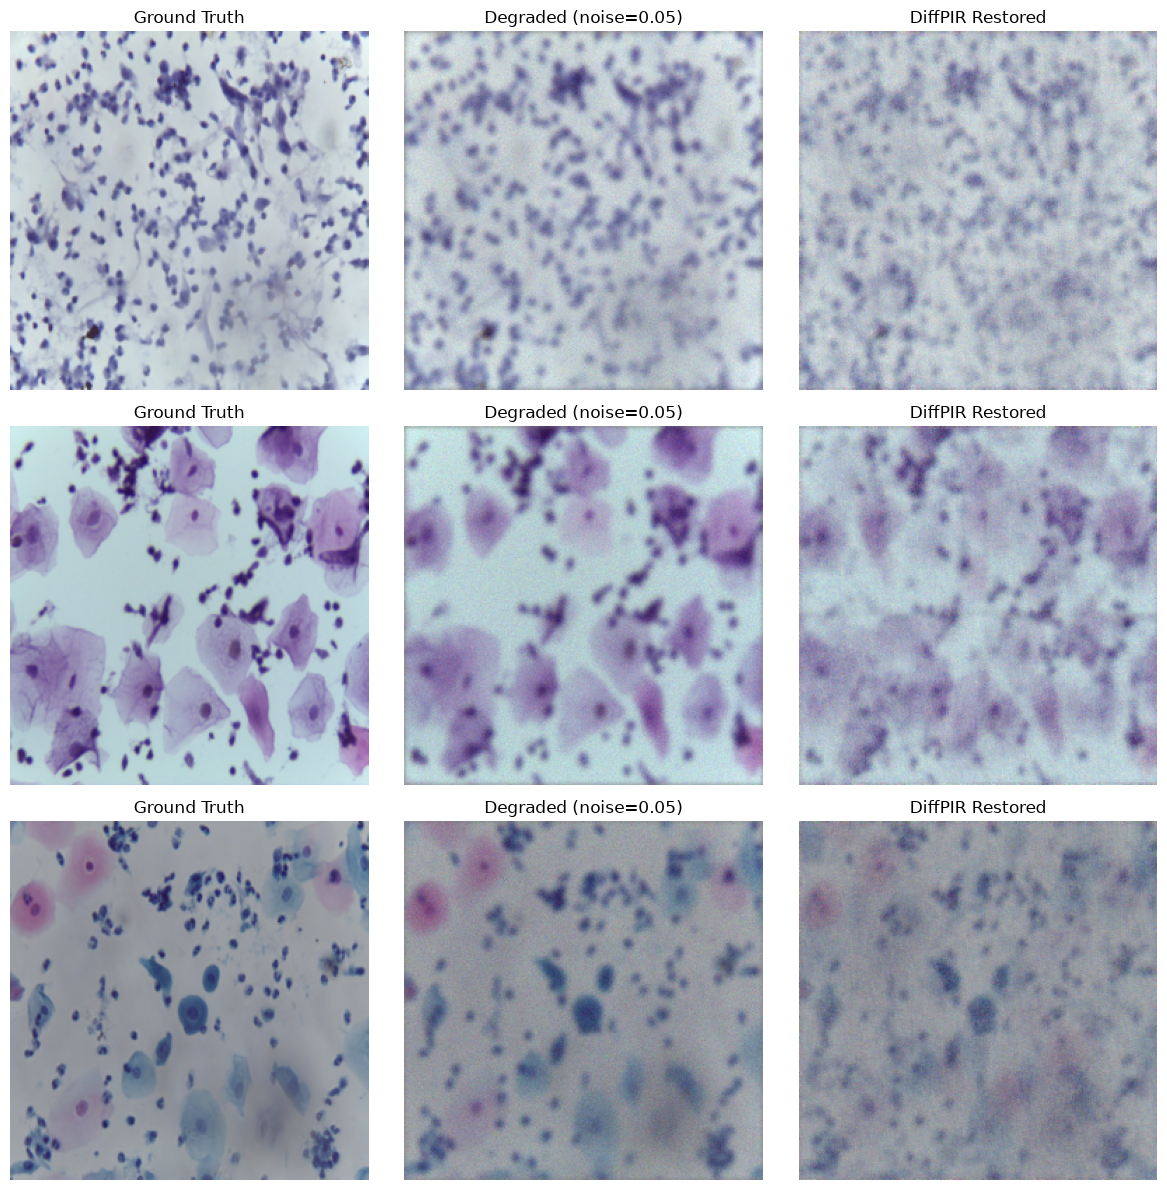

In [4]:
n_examples = 3
noise_level = 0.05

fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))

for i in range(n_examples):
    gt = test_dataset[i]
    degraded = degrade(gt, kernel_size=kernel_size, sigma=blur_sigma, noise_level=noise_level)

    print(f'Processando immagine {i+1}/{n_examples}...')
    restored = run_diffpir(
        degraded.to(device),
        num_steps=num_steps,
        noise_level=noise_level,
        kernel_size=kernel_size,
        blur_sigma=blur_sigma,
        lambda_=lambda_,
        zeta=zeta,
        t_start=t_start,
        weights_path=weights_path,
    )

    def norm01(t):
        """Convert to [0,1] numpy for display."""
        t = t * 0.5 + 0.5 if t.min() < 0 else t
        return t.clamp(0, 1).permute(1, 2, 0).numpy()

    axes[i, 0].imshow(norm01(gt))
    axes[i, 0].set_title('Ground Truth')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(norm01(degraded))
    axes[i, 1].set_title(f'Degraded (noise={noise_level})')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(norm01(restored))
    axes[i, 2].set_title('DiffPIR Restored')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Valutazione quantitativa
Calcolo PSNR e SSIM su un sottoinsieme del test set per tutti i livelli di rumore.

In [5]:
n_eval = config['diffpir'].get('max_test_images', 10)
results = []

for noise_level in noise_levels:
    psnr_list, ssim_list, time_list = [], [], []

    for i in tqdm(range(n_eval), desc=f'noise={noise_level}'):
        gt = test_dataset[i]
        degraded = degrade(gt, kernel_size=kernel_size, sigma=blur_sigma, noise_level=noise_level)

        restored, inference_time = run_diffpir(
            degraded.to(device),
            num_steps=num_steps,
            noise_level=noise_level,
            kernel_size=kernel_size,
            blur_sigma=blur_sigma,
            lambda_=lambda_,
            zeta=zeta,
            t_start=t_start,
            weights_path=weights_path,
            return_timing=True,
        )

        m = evaluate(restored, gt)
        psnr_list.append(m['psnr'])
        ssim_list.append(m['ssim'])
        time_list.append(inference_time)

    avg_psnr = np.mean(psnr_list)
    avg_ssim = np.mean(ssim_list)
    avg_time = np.mean(time_list)
    results.append({
        'method': 'diffpir',
        'noise_level': noise_level,
        'psnr': avg_psnr,
        'ssim': avg_ssim,
        'avg_inference_time': avg_time
    })
    print(f'[DiffPIR] noise={noise_level} | PSNR={avg_psnr:.2f} | SSIM={avg_ssim:.4f} | Time={avg_time:.1f}s')

df_results = pd.DataFrame(results)
df_results

noise=0.005:   0%|          | 0/10 [00:00<?, ?it/s]

[Device] CPU


noise=0.005:  10%|█         | 1/10 [00:02<00:22,  2.48s/it]

[Device] CPU


noise=0.005:  20%|██        | 2/10 [00:05<00:20,  2.61s/it]

...

[Device] CPU


noise=0.1: 100%|██████████| 10/10 [00:29<00:00,  3.01s/it]

noise=0.1: 100%|██████████| 10/10 [00:29<00:00,  2.93s/it]

[DiffPIR] noise=0.1 | PSNR=24.68 | SSIM=0.6630 | Time=2.8s


,method,noise_level,psnr,ssim,avg_inference_time
0,diffpir,0.005,16.671711,0.235172,2.556366
1,diffpir,0.010,17.317508,0.269936,2.727606
2,diffpir,0.050,22.489219,0.512236,2.818119
3,diffpir,0.100,24.679176,0.662958,2.836377


## Salvataggio risultati

In [6]:
output_dir = Path(config['eval']['results_dir']) / 'diffpir'
output_dir.mkdir(parents=True, exist_ok=True)

df_results.to_csv(output_dir / 'metrics.csv', index=False)
print(f'Risultati salvati in {output_dir / "metrics.csv"}')

Risultati salvati in results\diffpir\metrics.csv


## Confronto con altri metodi
Caricamento risultati TV e UNet per confronto finale.

| Ïƒ_n | DiffPIR PSNR | DiffPIR SSIM |
|---|---|---|
| 0.005 | 16.67 dB | 0.235 |
| 0.01 | 17.32 dB | 0.270 |
| 0.05 | 22.49 dB | 0.512 |
| 0.1 | 24.68 dB | 0.664 |

*Nota: colonne TV e UNet popolate dopo esecuzione dei rispettivi script.*

In [7]:
from src.plots.visualize import plot_metrics

results_dir = Path(config['eval']['results_dir'])

def load_metrics(method):
    p = results_dir / method / 'metrics.csv'
    return pd.read_csv(p) if p.exists() else None

df_tv = load_metrics('tv')
df_unet = load_metrics('unet')
df_diffpir = load_metrics('diffpir')

dfs = [df for df in [df_tv, df_unet, df_diffpir] if df is not None]
if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    display(df_all.pivot(index='noise_level', columns='method', values=['psnr', 'ssim']))
    plot_metrics(results_dir)
else:
    print('Esegui prima TV e UNet per il confronto completo.')

psnr                 ssim          
method         diffpir         tv   diffpir        tv
noise_level                                          
0.005        16.671711  30.408848  0.235172  0.895049
0.010        17.317508  30.376146  0.269936  0.893600
0.050        22.489219  29.192632  0.512236  0.827353
0.100        24.679176  25.969846  0.662958  0.594741

## Discussione

### Risultati Osservati
- **Basso rumore (Ïƒ=0.005-0.01)**: PSNR ~16-17 dB, SSIM ~0.24-0.27
  - Il modello fatica a distinguere rumore da dettagli fini cellulari
  - Rimuove dettagli che confonde con rumore, penalizzando il PSNR
- **Medio rumore (Ïƒ=0.05)**: PSNR ~22.5 dB, SSIM ~0.51
  - Buon bilanciamento: il modello pulisce efficacemente senza degradare troppo
- **Alto rumore (Ïƒ=0.1)**: PSNR ~24.7 dB, SSIM ~0.66
  - Miglior risultato: il guadagno netto della denoising Ã¨ massimo

### Performance
- ~2 sec/immagine su CPU (15 step, LightUNet 1.26M params)
- 20Ã— piÃ¹ lento di UNet (GPU), 5Ã— piÃ¹ veloce di TV